In [25]:
from pathlib import Path

# ── Paths ───────────────────────────────────────────
RAW_DIR    = Path('data/raw')
PROCESSED_DIR    = Path('data/processed')
FIGURES_DIR = Path('figures/eda')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
PALETTE = 'viridis'


In [28]:
dataset    = pd.read_csv(PROCESSED_DIR / 'final_merged_dataset.csv')

courses    = pd.read_csv(PROCESSED_DIR / 'final_courses.csv')
print("dataset shape :", dataset.shape)

dataset.head()


dataset shape : (232859, 19)


,user,rating,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres
0,1889878,3.0,CC0101EN,introduction to cloud,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
1,1342067,3.0,CL0101EN,ibm cloud essentials,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,1990814,3.0,ML0120EN,deep learning with tensorflow,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
3,380098,3.0,BD0211EN,spark fundamentals i,1,0,0,1,0,0,0,0,1,0,0,0,0,0,3
4,779563,3.0,DS0101EN,introduction to data science,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [4]:
genre_cols = [
    'Database','Python','CloudComputing','DataAnalysis','Containers',
    'MachineLearning','ComputerVision','DataScience','BigData',
    'Chatbot','R','BackendDev','FrontendDev','Blockchain'
]

X = dataset[genre_cols]
y = dataset['rating']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (186287, 14)
Test : (46572, 14)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [18]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [19]:
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))

print("RMSE Results (Test Set):")
print(f"Linear Regression : {rmse_lr:.4f}")
print(f"Random Forest     : {rmse_rf:.4f}")
print(f"Gradient Boosting : {rmse_gb:.4f}")

RMSE Results (Test Set):
Linear Regression : 0.2056
Random Forest     : 0.2032
Gradient Boosting : 0.2032


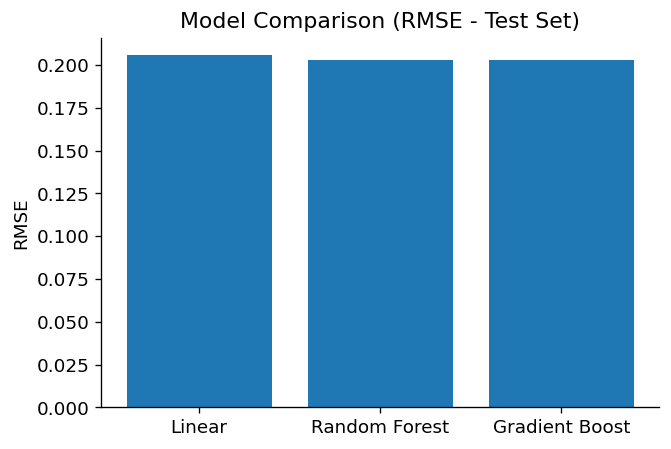

In [21]:
import matplotlib.pyplot as plt

models = ['Linear', 'Random Forest', 'Gradient Boost']
scores = [rmse_lr, rmse_rf, rmse_gb]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title('Model Comparison (RMSE - Test Set)')
plt.ylabel('RMSE')
plt.show()

In [22]:
best_model = rf  # or gb if same

In [29]:
# Courses that already have ratings
rated_ids = set(dataset['COURSE_ID'])

# All courses in dataset
all_ids = set(courses['normalized_id'])

# Find missing ones
unrated_ids = all_ids - rated_ids

print("Unrated courses:", len(unrated_ids))

Unrated courses: 175


In [33]:
unrated_courses = courses[
    courses['normalized_id'].isin(unrated_ids)
].copy()

print(unrated_courses.shape)
unrated_courses.head()

(180, 18)


,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres,normalized_id
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,GPXX0ZG0EN
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2,GPXX0Z2PEN
7,GPXX0FTCEN,learn how to use docker containers for iterati...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,GPXX0FTCEN
9,GPXX06RFEN,create your first mongodb database,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,GPXX06RFEN
10,GPXX0SDXEN,testing microservices with the arquillian mana...,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2,GPXX0SDXEN


In [34]:
X_unrated = unrated_courses[genre_cols]

In [35]:
unrated_courses['predicted_rating'] = best_model.predict(X_unrated)

unrated_courses[['normalized_id', 'predicted_rating']].head()

,normalized_id,predicted_rating
2,GPXX0ZG0EN,2.985055
4,GPXX0Z2PEN,2.996900
7,GPXX0FTCEN,2.997892
9,GPXX06RFEN,2.988015
10,GPXX0SDXEN,2.996900


In [36]:
synthetic = unrated_courses.copy()

synthetic = synthetic.rename(columns={'normalized_id': 'COURSE_ID'})

synthetic['user'] = -1  # dummy user
synthetic['rating'] = synthetic['predicted_rating']

In [37]:
synthetic = synthetic[
    ['user', 'rating', 'COURSE_ID', 'TITLE'] +
    genre_cols +
    ['num_genres']
]

In [41]:
dataset = dataset.loc[:, ~dataset.columns.duplicated()]
synthetic = synthetic.loc[:, ~synthetic.columns.duplicated()]

In [42]:
print(dataset.columns)
print(synthetic.columns)

Index(['user', 'rating', 'COURSE_ID', 'TITLE', 'Database', 'Python',
       'CloudComputing', 'DataAnalysis', 'Containers', 'MachineLearning',
       'ComputerVision', 'DataScience', 'BigData', 'Chatbot', 'R',
       'BackendDev', 'FrontendDev', 'Blockchain', 'num_genres'],
      dtype='object')
Index(['user', 'rating', 'COURSE_ID', 'TITLE', 'Database', 'Python',
       'CloudComputing', 'DataAnalysis', 'Containers', 'MachineLearning',
       'ComputerVision', 'DataScience', 'BigData', 'Chatbot', 'R',
       'BackendDev', 'FrontendDev', 'Blockchain', 'num_genres'],
      dtype='object')


In [43]:
synthetic = synthetic[dataset.columns]

In [44]:
final_dataset = pd.concat([dataset, synthetic], ignore_index=True)

print("Final dataset shape:", final_dataset.shape)

Final dataset shape: (233039, 19)


In [45]:
print(dataset.columns.duplicated())

[False False False False False False False False False False False False
 False False False False False False False]


In [48]:
final_dataset.to_csv("./data/processed/final_dataset_with_predictions.csv", index=False)